# Topic Prevalence — Agenda Divergence Grid

For each alternative outlet, plots **outlet topic prevalence** (y-axis) against **Tagesschau topic prevalence** (x-axis) for every Manual Topic Label from the merged BERTopic model. Each point is colored by which zone it falls into:

- **Amplification** — topic large in outlet, also present in the Tagesschau baseline.
- **Omission** — topic large in outlet but rare or absent in Tagesschau.
- **Mainstream-only** — topic large in Tagesschau but rare in outlet.

This is the visual companion to the Jensen–Shannon and entropy analysis for Mechanism 1.


In [47]:
import logging
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from adjustText import adjust_text

logging.getLogger("adjustText").setLevel(logging.ERROR)

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["figure.dpi"]  = 150

# ── Load ────────────────────────────────────────────────────────────────────
df = pd.read_csv("/Users/gretawette/Documents/Thesis/02_TopicModeling/outputs/03_new_topic_assignments.csv")

# ── Thresholds (symmetric: same rule on both sides of the diagonal) ─────────
SIGNIFICANT_SHARE = 0.045   # share considered "significant" on either axis
SHARE_MARGIN      = 0.01    # required gap between the two sides
COVERAGE_FLOOR    = 0.03    # secondary side must have at least this for "amp"
NICHE_HIGH        = 0.07    # focus topic threshold for niche / substitution
NICHE_LOW         = 0.035   # near-zero on the opposite axis
PARITY_MARGIN              = 0.006
PARITY_MIN_BASELINE_SHARE  = 0.045

OUTLET_RENAME = {"RT": "RT DE", "Nius": "NIUS"}
df["source"] = df["source"].replace(OUTLET_RENAME)
df = df[df["Manual Topic Label"].notna() & (df["Manual Topic Label"] != "")]

TAGESSCHAU = "Tagesschau"
ALT_OUTLETS = [s for s in sorted(df["source"].unique()) if s != TAGESSCHAU]

# ── Compute prevalence: share of each outlet's articles on each topic ───────
def prevalence(src_df):
    total = len(src_df)
    return src_df["Manual Topic Label"].value_counts() / total

ts_prev  = prevalence(df[df["source"] == TAGESSCHAU])
all_topics = sorted(df["Manual Topic Label"].unique())

outlet_prev = {src: prevalence(df[df["source"] == src]) for src in ALT_OUTLETS}

# ── Zone classifier ─────────────────────────────────────────────────────────
ZONE_COLORS = {
    "Amplification":    "#7e1b4f",
    "Substitution":     "#f46b26",
    "Mainstream-only":  "#13436d",
    "Parity":           "#2da095",
    "Other":            "#cccccc",
}

def classify_zone(x, y):
    if (y >= SIGNIFICANT_SHARE
            and x >= COVERAGE_FLOOR
            and y >= x + SHARE_MARGIN):
        return "Amplification"
    if y >= NICHE_HIGH and x <= NICHE_LOW:
        return "Substitution"
    if (x >= SIGNIFICANT_SHARE
            and y >= COVERAGE_FLOOR
            and x >= y + SHARE_MARGIN):
        return "Mainstream-strong"
    if x >= NICHE_HIGH and y <= NICHE_LOW:
        return "Mainstream-only"
    if x >= PARITY_MIN_BASELINE_SHARE and abs(y - x) <= PARITY_MARGIN:
        return "Parity"
    return "Other"

print("Loaded", len(df), "articles")
print("Outlets:", [TAGESSCHAU] + ALT_OUTLETS)
print("Topics:", len(all_topics))


Loaded 19812 articles
Outlets: ['Tagesschau', 'Antispiegel', 'Compact', 'Deutschlandkurier', 'NIUS', 'RT DE', 'Tichys Einblick']
Topics: 72


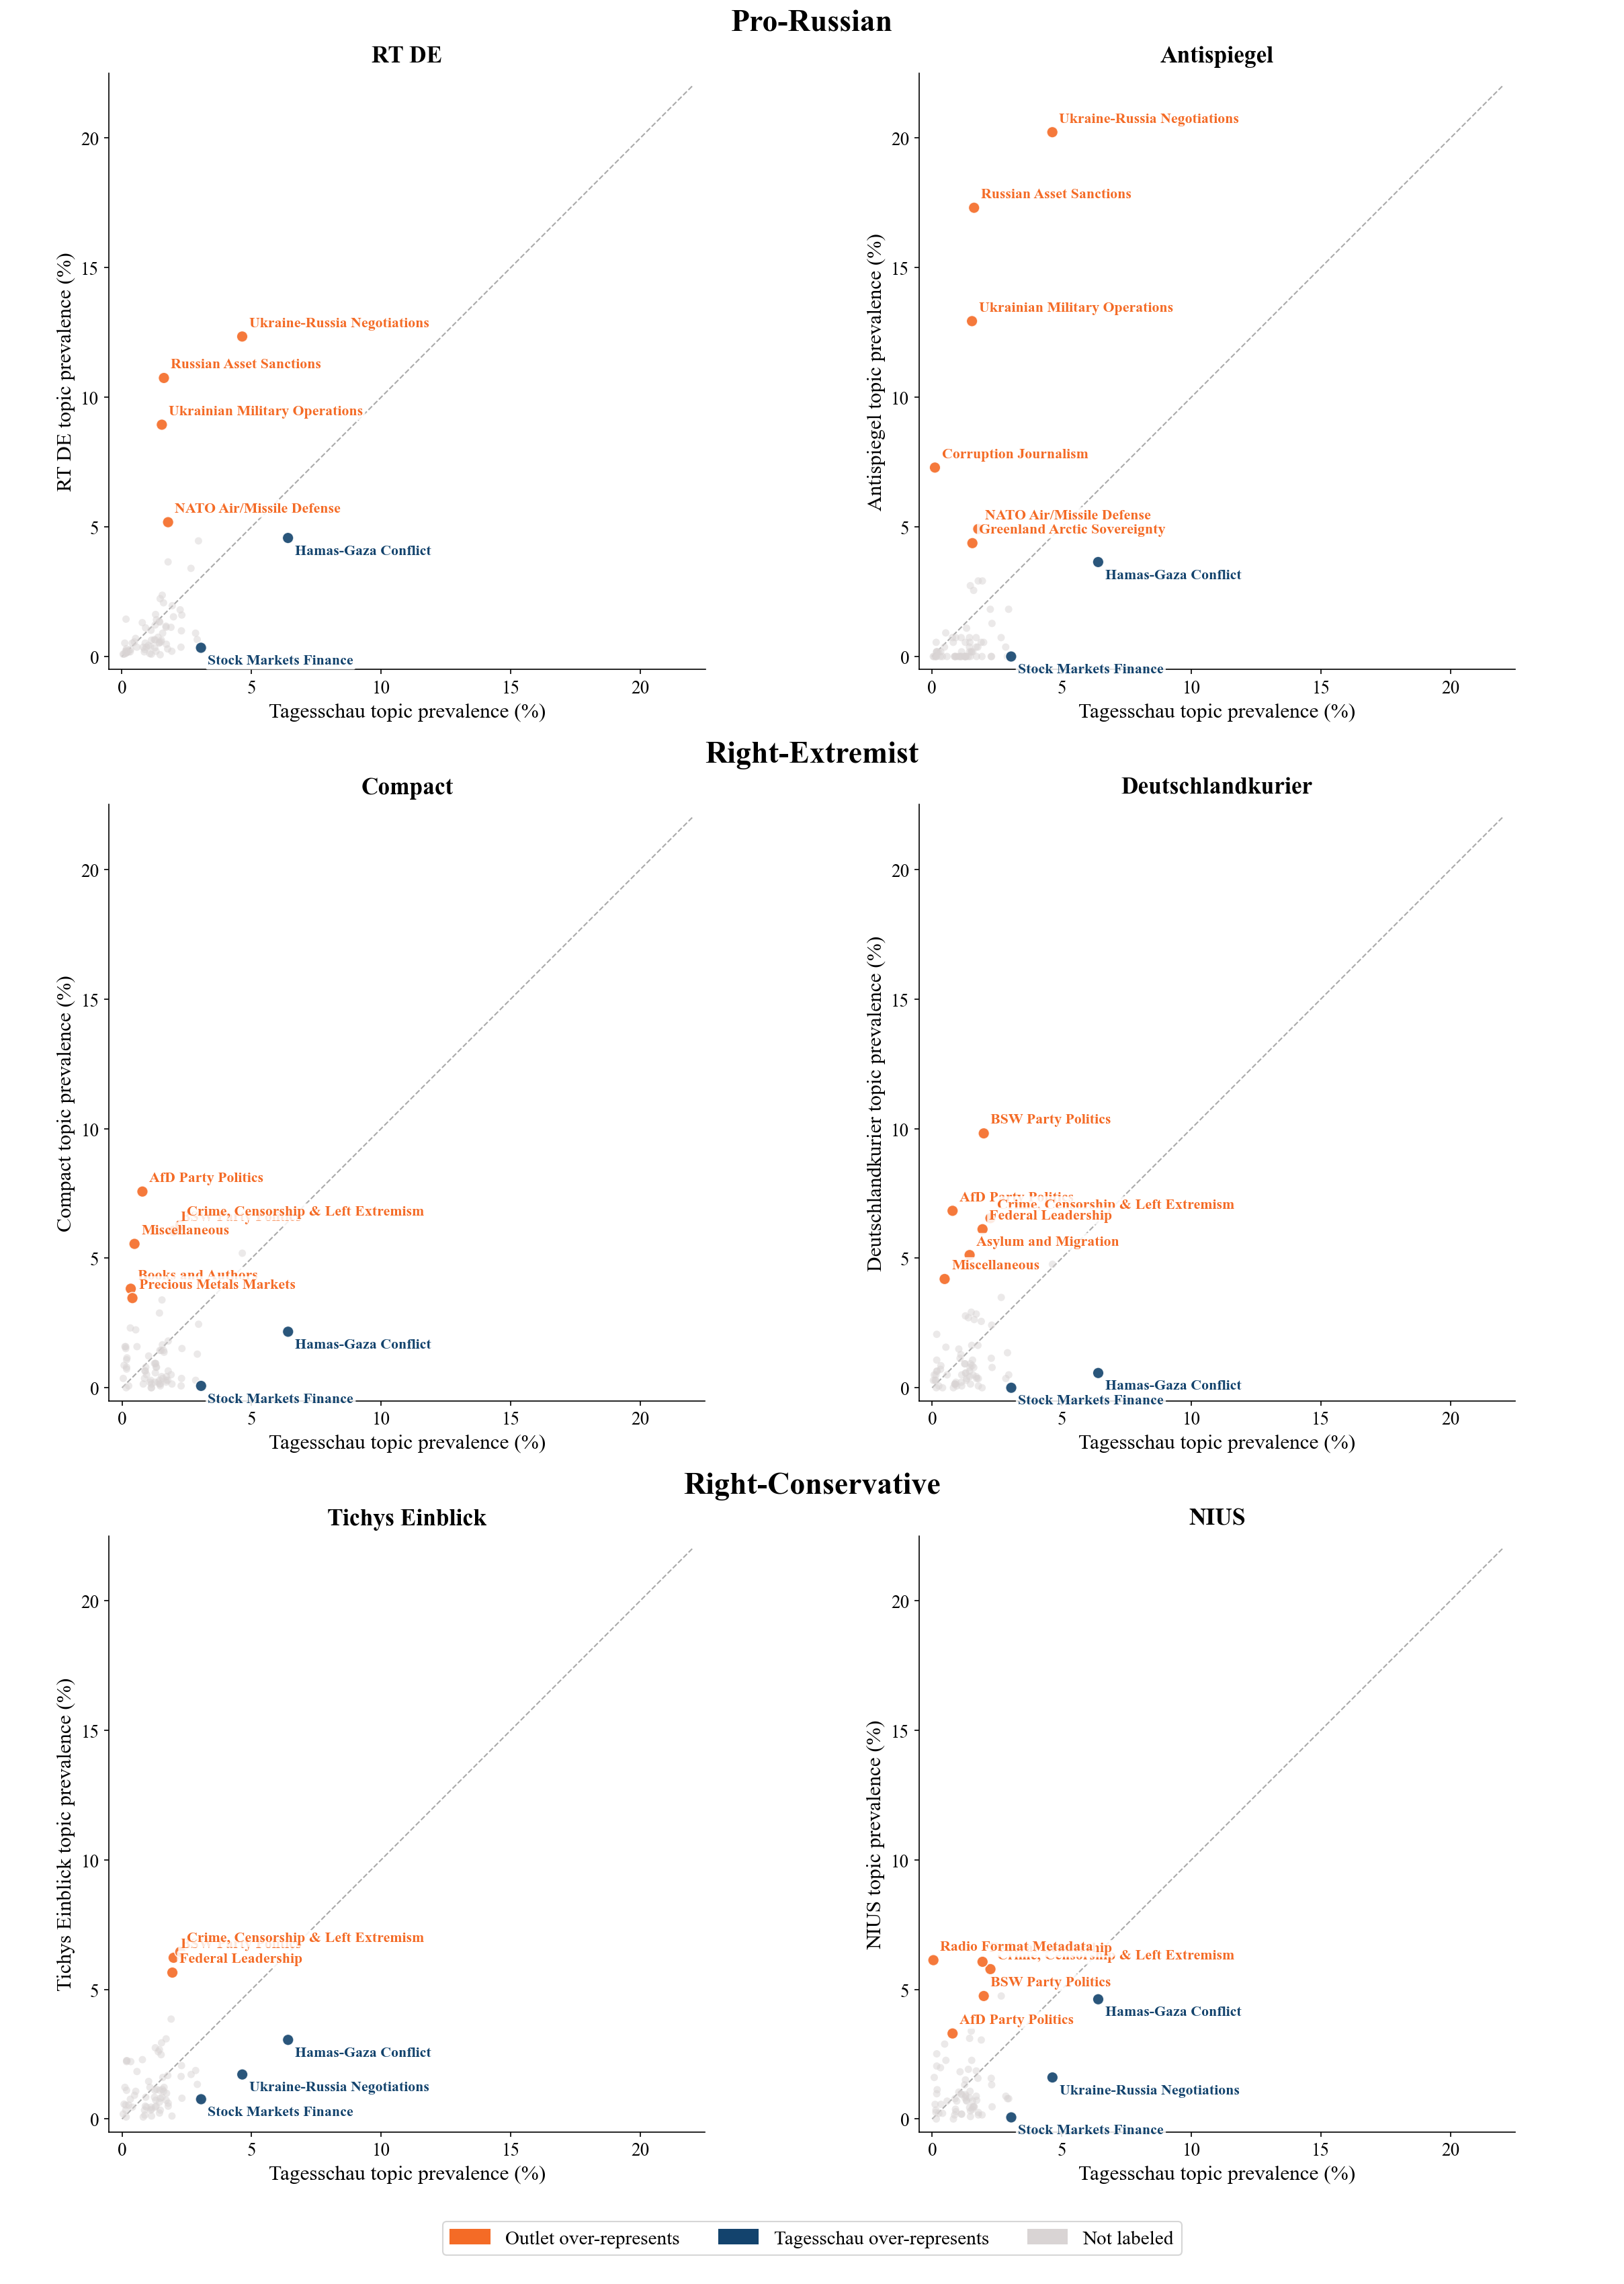

In [48]:
# ── Combined grid: 3 rows × 2 cols, grouped by political category ──────────
OUTLET_ORDER = [
    "RT DE",         "Antispiegel",
    "Compact",       "Deutschlandkurier",
    "Tichys Einblick", "NIUS",
]
OUTLET_ORDER = [o for o in OUTLET_ORDER if o in ALT_OUTLETS]

ROW_TITLES = ["Pro-Russian", "Right-Extremist", "Right-Conservative"]

NCOLS = 2
NROWS = 3

# Label + colour: zone rules from `classify_zone` in the previous cell plus
# a residual rule for clear diagonal splits that fall outside the strict
# corner zones.  The two sides are deliberately *asymmetric*: the blue
# (Tagesschau-over-represents) side uses looser thresholds so more
# mainstream-only topics surface, while the orange side stays strict.
RESIDUAL_GAP   = 0.015
RESIDUAL_FLOOR = 0.025
RESIDUAL_MIN   = 0.03

# Looser thresholds for the blue side only.
BLUE_RESIDUAL_GAP   = 0.01
BLUE_RESIDUAL_FLOOR = 0.025
BLUE_RESIDUAL_MIN   = 0.03

# Near-diagonal suppression: drop labels whose two prevalences are very close
# in absolute terms, unless at least one side is large enough that the topic
# is clearly notable.  Also asymmetric — blue clears the filter more easily.
NEAR_DIAG_GAP    = 0.025
NEAR_DIAG_BYPASS = 0.11

BLUE_NEAR_DIAG_GAP    = 0.012
BLUE_NEAR_DIAG_BYPASS = 0.07

COLOR_OUTLET = "#f46b26"
COLOR_TAGESSCHAU = "#13436d"
COLOR_GREY = "#d9d4d4"

def point_colour(x, y):
    """Return matplotlib colour or None (grey / unlabeled)."""
    z = classify_zone(x, y)
    if z == "Parity":
        return None
    if z in ("Amplification", "Substitution"):
        col = COLOR_OUTLET
    elif z in ("Mainstream-strong", "Mainstream-only"):
        col = COLOR_TAGESSCHAU
    elif y >= x:
        if max(x, y) < RESIDUAL_FLOOR:
            return None
        if y >= x + RESIDUAL_GAP and y >= RESIDUAL_MIN:
            col = COLOR_OUTLET
        else:
            return None
    else:
        if max(x, y) < BLUE_RESIDUAL_FLOOR:
            return None
        if x >= y + BLUE_RESIDUAL_GAP and x >= BLUE_RESIDUAL_MIN:
            col = COLOR_TAGESSCHAU
        else:
            return None

    if col == COLOR_TAGESSCHAU:
        gap, bypass = BLUE_NEAR_DIAG_GAP, BLUE_NEAR_DIAG_BYPASS
    else:
        gap, bypass = NEAR_DIAG_GAP, NEAR_DIAG_BYPASS
    if abs(y - x) < gap and max(x, y) < bypass:
        return None
    return col

# One sub-figure per row (row suptitles), plus a thin strip for the legend.
fig = plt.figure(figsize=(NCOLS * 8, NROWS * 7 + 1.55), layout="constrained")
subfigs = fig.subfigures(NROWS + 1, 1, height_ratios=[*([1] * NROWS), 0.11])

axes_flat = []
for row_idx in range(NROWS):
    sf = subfigs[row_idx]
    sf.suptitle(ROW_TITLES[row_idx], fontsize=22, fontweight="bold")
    row_axes = sf.subplots(1, NCOLS)
    axes_flat.extend(np.atleast_1d(row_axes).tolist())

# Precompute every dot once.  Both this labeled cell and the unlabeled
# follow-up cell read `dots_by_outlet` so the two figures are guaranteed
# to show the exact same set of grey / coloured points.
dots_by_outlet = {}
all_vals = []
for src in OUTLET_ORDER:
    grey_x, grey_y = [], []
    colored = []
    for topic in all_topics:
        x = float(ts_prev.get(topic, 0.0))
        y = float(outlet_prev[src].get(topic, 0.0))
        all_vals.append(x * 100)
        all_vals.append(y * 100)
        col = point_colour(x, y)
        if col is not None:
            colored.append((x * 100, y * 100, topic, col))
        else:
            grey_x.append(x * 100)
            grey_y.append(y * 100)
    dots_by_outlet[src] = {"grey": (grey_x, grey_y), "colored": colored}
axis_max_pct = min(float(np.ceil(max(all_vals) + 1)), 35.0)

for ax, src in zip(axes_flat, OUTLET_ORDER):
    grey_x, grey_y = dots_by_outlet[src]["grey"]
    colored = dots_by_outlet[src]["colored"]

    ax.scatter(grey_x, grey_y, c=COLOR_GREY, s=28, alpha=0.50,
               edgecolors="none", zorder=1)

    if colored:
        ax.scatter([p[0] for p in colored], [p[1] for p in colored],
                   c=[p[3] for p in colored], s=65, alpha=0.90,
                   edgecolors="white", linewidths=0.8, zorder=3)

    # Place each label close to its dot, with `adjustText` resolving any
    # overlap between labels (and between labels and dots).  Each label is
    # initially anchored a small offset off its dot so the leader line has a
    # direction; adjustText then nudges to remove overlaps.
    if colored:
        # Place each label at a small fixed offset from its dot.  No leader
        # lines, no adjustText — overlaps are expected and will be cleaned up
        # manually in Canva.  Side of the dot is chosen so the label sits on
        # the "outside" of the diagonal (away from the y = x line) and stays
        # in-panel near the right edge.
        dx_data = axis_max_pct * 0.012
        dy_data = axis_max_pct * 0.012
        for px, py, lbl, col in colored:
            if py >= px:
                ax_dx = -dx_data if px > axis_max_pct * 0.55 else dx_data
                ax_dy = dy_data
                ha = "right" if ax_dx < 0 else "left"
                va = "bottom"
            else:
                ax_dx = dx_data
                ax_dy = -dy_data
                ha = "left"
                va = "top"
            ax.text(
                px + ax_dx, py + ax_dy, lbl,
                fontsize=10.5, color=col, fontweight="semibold",
                ha=ha, va=va, zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white",
                          ec="none", alpha=0.85),
            )

    ax.plot([0, axis_max_pct], [0, axis_max_pct],
            color="#aaaaaa", linewidth=1.0, linestyle="--", zorder=0)

    # Equal scale on both axes.
    ax.set_xlim(-0.5, axis_max_pct + 0.5)
    ax.set_ylim(-0.5, axis_max_pct + 0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Tagesschau topic prevalence (%)", fontsize=15)
    ax.set_ylabel(f"{src} topic prevalence (%)", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(src, fontsize=17, fontweight="bold", pad=8)

for ax in axes_flat[len(OUTLET_ORDER):]:
    ax.set_visible(False)

# Shared legend (reference-style: orange / blue / not labeled)
handles = [
    mpatches.Patch(color=COLOR_OUTLET, label="Outlet over-represents"),
    mpatches.Patch(color=COLOR_TAGESSCHAU, label="Tagesschau over-represents"),
    mpatches.Patch(color=COLOR_GREY, label="Not labeled"),
]
legend_ax = subfigs[NROWS].subplots(1, 1)
legend_ax.axis("off")
legend_ax.legend(
    handles=handles,
    loc="center",
    fontsize=14,
    frameon=True,
    ncol=3,
)

plt.show()
